# Notebook 01 — Data Audit

Validates the contents of `data/mlb.db` before model training.

**Checks:**
1. Row counts and date coverage per table
2. Missing-value audit (NULLs by column)
3. Target variable distribution (home_runs, away_runs, total_runs)
4. Sportsbook odds coverage and line distribution
5. Weather data completeness
6. Elo rating distribution over time
7. Pitcher feature completeness
8. Park factor sanity check
9. Data quality summary — go/no-go for Phase 3

In [1]:
import sys
sys.path.insert(0, '..')

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from mlb.db import get_conn

DB_PATH = '../data/mlb.db'
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('imports OK')

imports OK


## 1. Row Counts & Date Coverage

In [2]:
with get_conn(DB_PATH) as conn:
    tables = [
        'games', 'team_stats', 'pitchers', 'weather',
        'sportsbook_odds', 'kalshi_markets', 'elo_ratings',
        'stadiums', 'scrape_log'
    ]
    counts = {}
    for t in tables:
        try:
            n = conn.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
            counts[t] = n
        except Exception as e:
            counts[t] = f'ERROR: {e}'

pd.DataFrame.from_dict(counts, orient='index', columns=['rows'])

,rows
games,4048
team_stats,8044
pitchers,34185
weather,894
sportsbook_odds,5946
kalshi_markets,0
elo_ratings,5136
stadiums,30
scrape_log,7


In [3]:
with get_conn(DB_PATH) as conn:
    coverage = pd.read_sql_query(
        '''
        SELECT season,
               COUNT(*) as total_games,
               SUM(CASE WHEN status = 'Final' THEN 1 ELSE 0 END) as final_games,
               SUM(CASE WHEN total_runs IS NOT NULL THEN 1 ELSE 0 END) as with_total,
               MIN(date) as first_date,
               MAX(date) as last_date
        FROM games
        GROUP BY season
        ORDER BY season
        ''',
        conn
    )

coverage['completeness_%'] = (coverage['with_total'] / coverage['total_games'] * 100).round(1)
print(coverage.to_string(index=False))

 season  total_games  final_games  with_total first_date  last_date  completeness_%
   2022         2430         2430        2430 2022-04-07 2022-10-05           100.0
   2023          843          843         840 2023-03-30 2023-05-31            99.6
   2024          775          775         767 2024-04-01 2024-05-28            99.0


## 2. Missing Value Audit

In [4]:
with get_conn(DB_PATH) as conn:
    games = pd.read_sql_query(
        "SELECT * FROM games WHERE status = 'Final'",
        conn
    )

null_pct = (games.isna().sum() / len(games) * 100).round(1)
null_df = pd.DataFrame({'null_count': games.isna().sum(), 'null_%': null_pct})
null_df[null_df['null_count'] > 0].sort_values('null_%', ascending=False)

,null_count,null_%
home_score,11,0.3
away_score,11,0.3
total_runs,11,0.3


In [5]:
# Pitcher feature null rates
with get_conn(DB_PATH) as conn:
    pitchers = pd.read_sql_query(
        "SELECT * FROM pitchers WHERE is_starter = 1",
        conn
    )

cols_of_interest = ['era_season', 'fip_season', 'k9_season', 'bb9_season', 'days_rest']
null_sp = pitchers[cols_of_interest].isna().mean().mul(100).round(1).rename('null_%')
print('Starter null rates (%):')
print(null_sp.to_string())

Starter null rates (%):
era_season      0.0
fip_season      0.0
k9_season       0.0
bb9_season      0.0
days_rest     100.0


In [6]:
# Weather null rates (outdoor games only)
with get_conn(DB_PATH) as conn:
    weather = pd.read_sql_query('SELECT * FROM weather', conn)
    stadiums = pd.read_sql_query('SELECT team, is_dome FROM stadiums', conn)

print(f'Weather rows: {len(weather)}')
weather_cols = ['temp_f', 'wind_speed_mph', 'wind_dir_deg', 'humidity']
w_null = weather[weather_cols].isna().mean().mul(100).round(1).rename('null_%')
print('\nWeather null rates (%):')
print(w_null.to_string())
print(f'\nDome stadiums: {stadiums["is_dome"].sum()} / {len(stadiums)}')

Weather rows: 894

Weather null rates (%):
temp_f            7.0
wind_speed_mph    7.0
wind_dir_deg      7.0
humidity          7.0

Dome stadiums: 2 / 30


## 3. Target Variable Distributions

In [7]:
with get_conn(DB_PATH) as conn:
    scores = pd.read_sql_query(
        "SELECT home_score, away_score, home_score + away_score as total FROM games "
        "WHERE status='Final' AND home_score IS NOT NULL",
        conn
    )

print('Target variable summary:')
print(scores[['home_score','away_score','total']].describe().round(2).to_string())

Target variable summary:
       home_score  away_score    total
count     4037.00     4037.00  4037.00
mean         4.35        4.33     8.68
std          3.05        3.20     4.43
min          0.00        0.00     1.00
25%          2.00        2.00     5.00
50%          4.00        4.00     8.00
75%          6.00        6.00    11.00
max         21.00       28.00    33.00


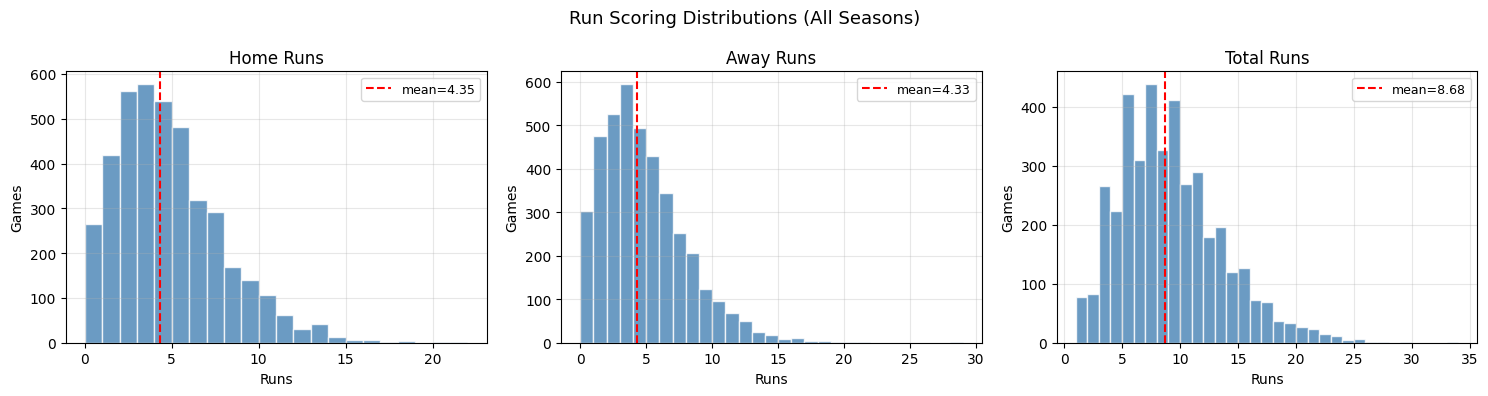

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label in zip(
    axes,
    ['home_score', 'away_score', 'total'],
    ['Home Runs', 'Away Runs', 'Total Runs']
):
    vals = scores[col].dropna()
    bins = range(int(vals.min()), int(vals.max()) + 2)
    ax.hist(vals, bins=bins, edgecolor='white', alpha=0.8, color='steelblue')
    ax.set_title(label)
    ax.set_xlabel('Runs')
    ax.set_ylabel('Games')
    # Poisson mean line
    ax.axvline(vals.mean(), color='red', linestyle='--', label=f'mean={vals.mean():.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Run Scoring Distributions (All Seasons)', fontsize=13)
plt.tight_layout()
plt.show()

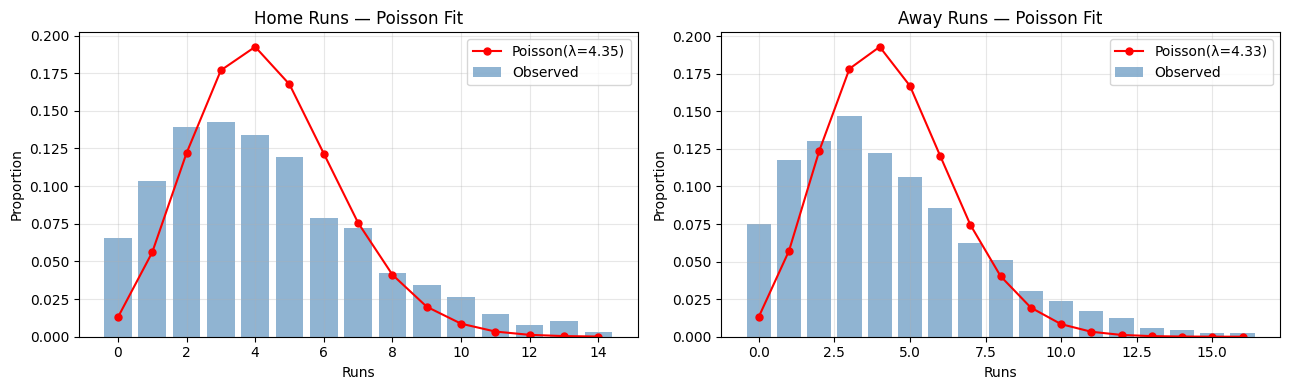

home_score: mean=4.352, var=9.321, dispersion=2.142  *** OVERDISPERSED — consider NegBinom ***
away_score: mean=4.327, var=10.210, dispersion=2.360  *** OVERDISPERSED — consider NegBinom ***


In [9]:
# Poisson goodness-of-fit visual: overlay theoretical Poisson PMF
from scipy.stats import poisson

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label in [
    (axes[0], 'home_score', 'Home Runs'),
    (axes[1], 'away_score', 'Away Runs')
]:
    vals = scores[col].dropna().astype(int)
    lam = vals.mean()
    k_max = int(vals.quantile(0.995))
    ks = np.arange(0, k_max + 1)

    # Observed proportions
    observed = vals.value_counts(normalize=True).reindex(ks, fill_value=0)
    ax.bar(ks, observed.values, alpha=0.6, label='Observed', color='steelblue')

    # Theoretical Poisson
    ax.plot(ks, poisson.pmf(ks, lam), 'ro-', ms=5, label=f'Poisson(λ={lam:.2f})')

    ax.set_title(f'{label} — Poisson Fit')
    ax.set_xlabel('Runs')
    ax.set_ylabel('Proportion')
    ax.legend()

plt.tight_layout()
plt.show()

# Overdispersion check
for col in ['home_score', 'away_score']:
    vals = scores[col].dropna()
    ratio = vals.var() / vals.mean()
    flag = '*** OVERDISPERSED — consider NegBinom ***' if ratio > 1.2 else 'OK'
    print(f'{col}: mean={vals.mean():.3f}, var={vals.var():.3f}, dispersion={ratio:.3f}  {flag}')

## 4. Sportsbook Odds Coverage

In [10]:
with get_conn(DB_PATH) as conn:
    odds = pd.read_sql_query('SELECT * FROM sportsbook_odds', conn)

print(f'Odds rows: {len(odds)}')
print(f'Date range: {odds["date"].min()} to {odds["date"].max()}')
print(f'Books: {sorted(odds["book"].unique())}')
print(f'\nTotal open null%: {odds["total_open"].isna().mean()*100:.1f}%')
print(f'Total close null%: {odds["total_close"].isna().mean()*100:.1f}%')

Odds rows: 5946
Date range: 2022-04-07 to 2024-04-01
Books: ['bet365', 'betmgm', 'caesars', 'draftkings', 'fanduel']

Total open null%: 1.0%
Total close null%: 0.0%


In [11]:
# Line distribution
pinnacle = odds[odds['book'] == 'pinnacle'][['date', 'total_open', 'total_close']].dropna()

if len(pinnacle) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    pinnacle['total_open'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Pinnacle Opening Total Line')
    axes[0].set_xlabel('Total')

    movement = pinnacle['total_close'] - pinnacle['total_open']
    movement.hist(bins=30, ax=axes[1], color='darkorange', edgecolor='white')
    axes[1].set_title('Line Movement (Close - Open)')
    axes[1].set_xlabel('Movement')
    axes[1].axvline(0, color='red', linestyle='--')

    plt.tight_layout()
    plt.show()

    print(f'Pinnacle close total: mean={pinnacle["total_close"].mean():.2f}, '
          f'std={pinnacle["total_close"].std():.2f}')
    print(f'Line movement: mean={movement.mean():.3f}, pct non-zero={( movement != 0).mean()*100:.1f}%')
else:
    print('No Pinnacle odds in DB yet')

No Pinnacle odds in DB yet


## 5. Weather Completeness

In [12]:
with get_conn(DB_PATH) as conn:
    # Games that have weather vs. don't
    r = conn.execute(
        """SELECT
             COUNT(*) as total_final,
             SUM(CASE WHEN w.game_id IS NOT NULL THEN 1 ELSE 0 END) as with_weather,
             SUM(CASE WHEN w.game_id IS NULL THEN 1 ELSE 0 END) as missing_weather
           FROM games g
           LEFT JOIN weather w ON w.game_id = g.game_id
           WHERE g.status = 'Final'"""
    ).fetchone()
    print(f'Final games: {r[0]}, with weather: {r[1]}, missing: {r[2]}')
    print(f'Weather coverage: {r[1]/r[0]*100:.1f}%')

    # Wind direction breakdown
    wdir = conn.execute(
        "SELECT wind_dir_label, COUNT(*) as n FROM weather GROUP BY wind_dir_label ORDER BY n DESC"
    ).fetchall()
    print('\nWind direction labels:')
    for wd in wdir:
        print(f'  {str(wd["wind_dir_label"]):<15} {wd["n"]}')

Final games: 4048, with weather: 894, missing: 3154
Weather coverage: 22.1%

Wind direction labels:
  cross_left      282
  out             219
  cross_right     193
  in              137
  None            63


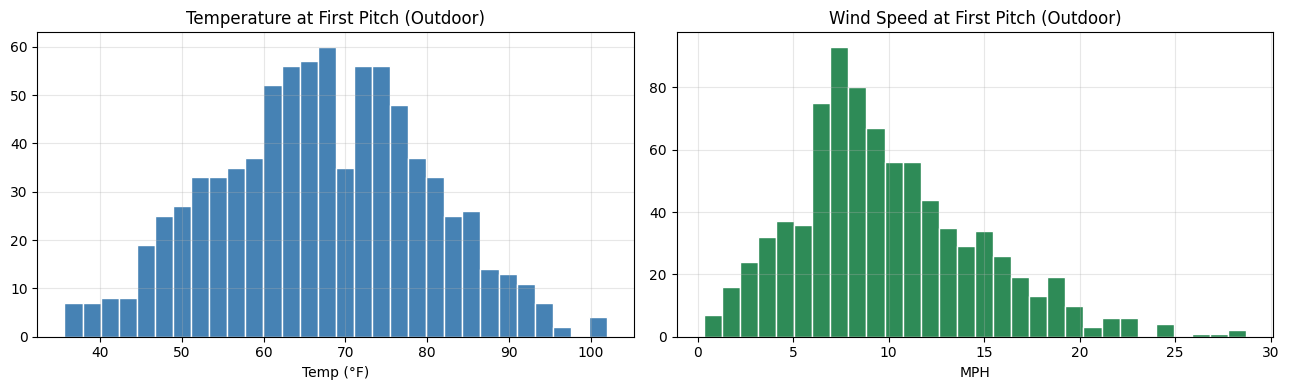

Temp: mean=67.0F, std=12.8
Wind: mean=9.9mph, std=4.8


In [13]:
# Temp and wind distributions
with get_conn(DB_PATH) as conn:
    wx = pd.read_sql_query(
        "SELECT temp_f, wind_speed_mph, is_dome FROM weather WHERE temp_f IS NOT NULL",
        conn
    )

outdoor = wx[wx['is_dome'] == 0]

if len(outdoor) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    outdoor['temp_f'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Temperature at First Pitch (Outdoor)')
    axes[0].set_xlabel('Temp (°F)')

    outdoor['wind_speed_mph'].hist(bins=30, ax=axes[1], color='seagreen', edgecolor='white')
    axes[1].set_title('Wind Speed at First Pitch (Outdoor)')
    axes[1].set_xlabel('MPH')

    plt.tight_layout()
    plt.show()
    print(f'Temp: mean={outdoor["temp_f"].mean():.1f}F, std={outdoor["temp_f"].std():.1f}')
    print(f'Wind: mean={outdoor["wind_speed_mph"].mean():.1f}mph, std={outdoor["wind_speed_mph"].std():.1f}')

## 6. Elo Rating Distribution

In [14]:
with get_conn(DB_PATH) as conn:
    elo = pd.read_sql_query(
        "SELECT team, date, elo, season FROM elo_ratings ORDER BY date",
        conn
    )

elo['date'] = pd.to_datetime(elo['date'])

# End-of-season rankings
for season in sorted(elo['season'].unique()):
    season_df = elo[elo['season'] == season]
    last_date = season_df['date'].max()
    final = season_df[season_df['date'] == last_date].sort_values('elo', ascending=False)
    print(f'\n{season} end-of-season Elo (top 5 / bottom 5):')
    print('  Top:   ', ', '.join(f"{r['team']}={r['elo']:.0f}" for _, r in final.head(5).iterrows()))
    print('  Bottom:', ', '.join(f"{r['team']}={r['elo']:.0f}" for _, r in final.tail(5).iterrows()))


2022 end-of-season Elo (top 5 / bottom 5):
  Top:    ATL=1640, LAD=1637, STL=1615, HOU=1596, TBR=1585
  Bottom: TEX=1416, OAK=1414, MIA=1397, DET=1392, PIT=1375

2023 end-of-season Elo (top 5 / bottom 5):
  Top:    TBR=1625, ATL=1612, NYM=1580, MIL=1562, TOR=1555
  Bottom: WSN=1430, SFG=1419, COL=1405, KCR=1385, OAK=1383

2024 end-of-season Elo (top 5 / bottom 5):
  Top:    ATL=1612, NYM=1594, BAL=1556, MIL=1555, CHC=1554
  Bottom: WSN=1445, MIN=1435, MIA=1433, OAK=1431, CHW=1396


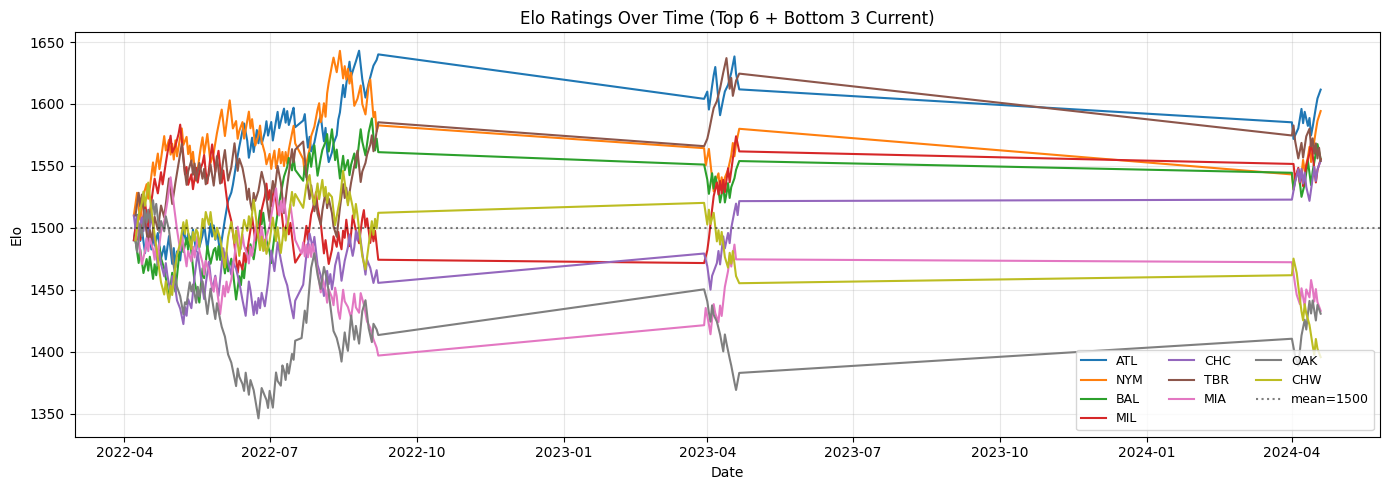

In [15]:
# Elo over time for top teams
with get_conn(DB_PATH) as conn:
    final_elos = pd.read_sql_query(
        """SELECT team, elo FROM elo_ratings
           WHERE season = (SELECT MAX(season) FROM elo_ratings)
           AND date = (SELECT MAX(date) FROM elo_ratings)
           ORDER BY elo DESC""",
        conn
    )

top_teams = final_elos.head(6)['team'].tolist()
bottom_teams = final_elos.tail(3)['team'].tolist()
highlight = top_teams + bottom_teams

fig, ax = plt.subplots(figsize=(14, 5))
for team in highlight:
    team_data = elo[elo['team'] == team].sort_values('date')
    ax.plot(team_data['date'], team_data['elo'], label=team, linewidth=1.5)

ax.axhline(1500, color='black', linestyle=':', alpha=0.5, label='mean=1500')
ax.set_title('Elo Ratings Over Time (Top 6 + Bottom 3 Current)')
ax.set_xlabel('Date')
ax.set_ylabel('Elo')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

## 7. Pitcher Feature Completeness

In [16]:
with get_conn(DB_PATH) as conn:
    sp = pd.read_sql_query(
        "SELECT p.*, g.date, g.season FROM pitchers p JOIN games g ON g.game_id = p.game_id "
        "WHERE p.is_starter = 1",
        conn
    )

print(f'Total starter rows: {len(sp)}')
print(f'Unique pitchers: {sp["pitcher_id"].nunique()}')
print(f'Seasons: {sorted(sp["season"].unique())}')

sp_cols = ['era_season', 'fip_season', 'k9_season', 'bb9_season', 'hr9_season', 'velocity_avg']
null_rates = sp[sp_cols].isna().mean().mul(100).round(1)
print('\nNull rates (%):')
for col, pct in null_rates.items():
    bar = '#' * int(pct / 2)
    print(f'  {col:<15} {pct:5.1f}%  {bar}')

Total starter rows: 8050
Unique pitchers: 490
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]

Null rates (%):
  era_season        0.0%  
  fip_season        0.0%  
  k9_season         0.0%  
  bb9_season        0.0%  
  hr9_season        0.0%  
  velocity_avg    100.0%  ##################################################


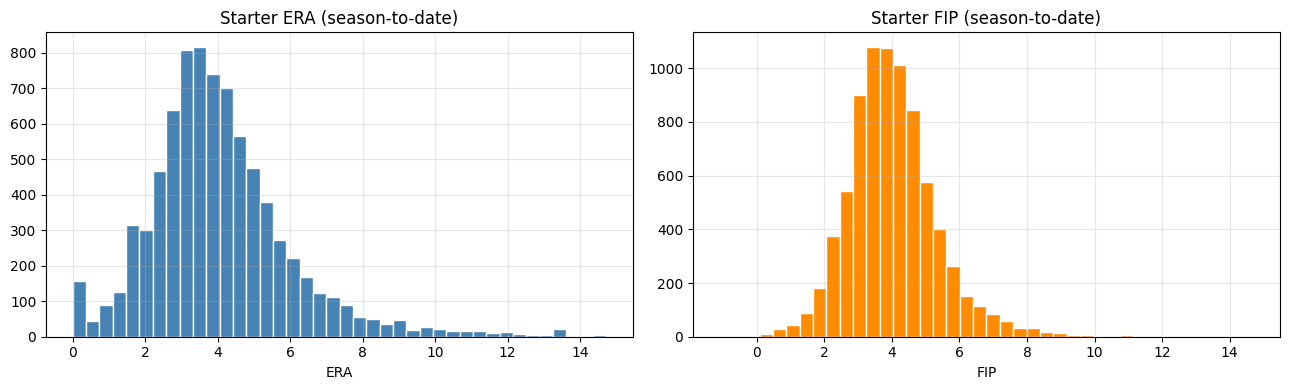

ERA: mean=4.07, median=3.81
FIP: mean=4.03, median=3.90


In [17]:
# ERA and FIP distributions for starters
sp_valid = sp.dropna(subset=['era_season', 'fip_season'])
# Cap extreme values for display
sp_valid = sp_valid[(sp_valid['era_season'] < 15) & (sp_valid['fip_season'] < 15)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sp_valid['era_season'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Starter ERA (season-to-date)')
axes[0].set_xlabel('ERA')

sp_valid['fip_season'].hist(bins=40, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Starter FIP (season-to-date)')
axes[1].set_xlabel('FIP')

plt.tight_layout()
plt.show()
print(f'ERA: mean={sp_valid["era_season"].mean():.2f}, median={sp_valid["era_season"].median():.2f}')
print(f'FIP: mean={sp_valid["fip_season"].mean():.2f}, median={sp_valid["fip_season"].median():.2f}')

## 8. Park Factor Sanity Check

In [18]:
with get_conn(DB_PATH) as conn:
    parks = pd.read_sql_query(
        "SELECT team, stadium_name, park_run_factor, park_hr_factor, elevation_ft, is_dome "
        "FROM stadiums ORDER BY park_run_factor DESC",
        conn
    )

print('Park run factors (sorted):')
print(parks[['team', 'stadium_name', 'park_run_factor', 'elevation_ft', 'is_dome']].to_string(index=False))

Park run factors (sorted):
team                stadium_name  park_run_factor  elevation_ft  is_dome
 COL                 Coors Field             1.26        5183.0        0
 CIN    Great American Ball Park             1.12         490.0        0
 TEX            Globe Life Field             1.10         551.0        0
 PHI          Citizens Bank Park             1.08          39.0        0
 NYY              Yankee Stadium             1.07          55.0        0
 BOS                 Fenway Park             1.06          20.0        0
 CHC               Wrigley Field             1.06         596.0        0
 ATL                 Truist Park             1.05        1050.0        0
 MIL       American Family Field             1.03         635.0        0
 STL               Busch Stadium             1.02         465.0        0
 MIN                Target Field             1.01         830.0        0
 HOU            Minute Maid Park             1.00          43.0        0
 LAA               Angel

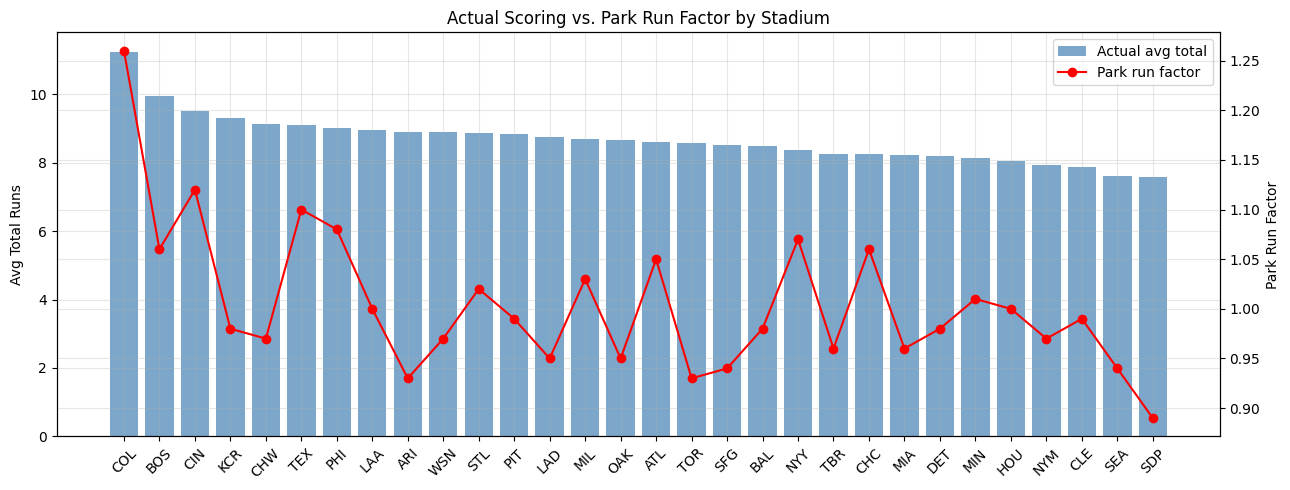

Correlation (actual avg vs park_run_factor): r=0.708


In [19]:
# Actual total runs per park vs park_run_factor
with get_conn(DB_PATH) as conn:
    actual = pd.read_sql_query(
        """SELECT g.home_team, AVG(g.total_runs) as avg_total,
                  COUNT(*) as games, s.park_run_factor
           FROM games g
           JOIN stadiums s ON s.team = g.home_team
           WHERE g.status = 'Final' AND g.total_runs IS NOT NULL
           GROUP BY g.home_team
           ORDER BY avg_total DESC""",
        conn
    )

fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(actual))
ax.bar(x, actual['avg_total'], color='steelblue', alpha=0.7, label='Actual avg total')
ax2 = ax.twinx()
ax2.plot(x, actual['park_run_factor'], 'ro-', ms=6, label='Park run factor')
ax.set_xticks(list(x))
ax.set_xticklabels(actual['home_team'], rotation=45)
ax.set_ylabel('Avg Total Runs')
ax2.set_ylabel('Park Run Factor')
ax.set_title('Actual Scoring vs. Park Run Factor by Stadium')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

corr = actual['avg_total'].corr(actual['park_run_factor'])
print(f'Correlation (actual avg vs park_run_factor): r={corr:.3f}')

## 9. Feature Matrix Smoke Test

In [20]:
from mlb.features import build_features, FEATURE_COLS, TARGET_COLS

df = build_features(start_date='2022-04-07', end_date='2022-09-23', db_path=DB_PATH)

print(f'Feature matrix: {df.shape}')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Targets: {TARGET_COLS}')

Feature matrix: (2263, 60)
Date range: 2022-04-07 to 2022-09-23
Features: 49
Targets: ['home_runs', 'away_runs', 'total_runs']


In [21]:
# Null rates in feature matrix
feat_nulls = df[FEATURE_COLS].isna().mean().mul(100).round(1).sort_values(ascending=False)
print('Feature null rates (top 20):')
print(feat_nulls.head(20).to_string())

Feature null rates (top 20):
precip_prob             100.0
temp_f                   63.9
humidity                 63.9
wind_speed_mph           63.9
wind_dir_in              61.1
wind_dir_cross_left      61.1
wind_dir_cross_right     61.1
wind_dir_out             61.1
line_movement            48.1
total_line_open          48.1
total_line_close         47.8
sp_fip_combined          12.1
sp_k9_combined           12.1
sp_era_l3_combined       12.1
away_sp_days_rest         8.2
away_sp_era_l3            8.2
away_sp_era_season        8.2
away_sp_k9_season         8.2
away_sp_bb9_season        8.2
away_sp_fip_season        8.2


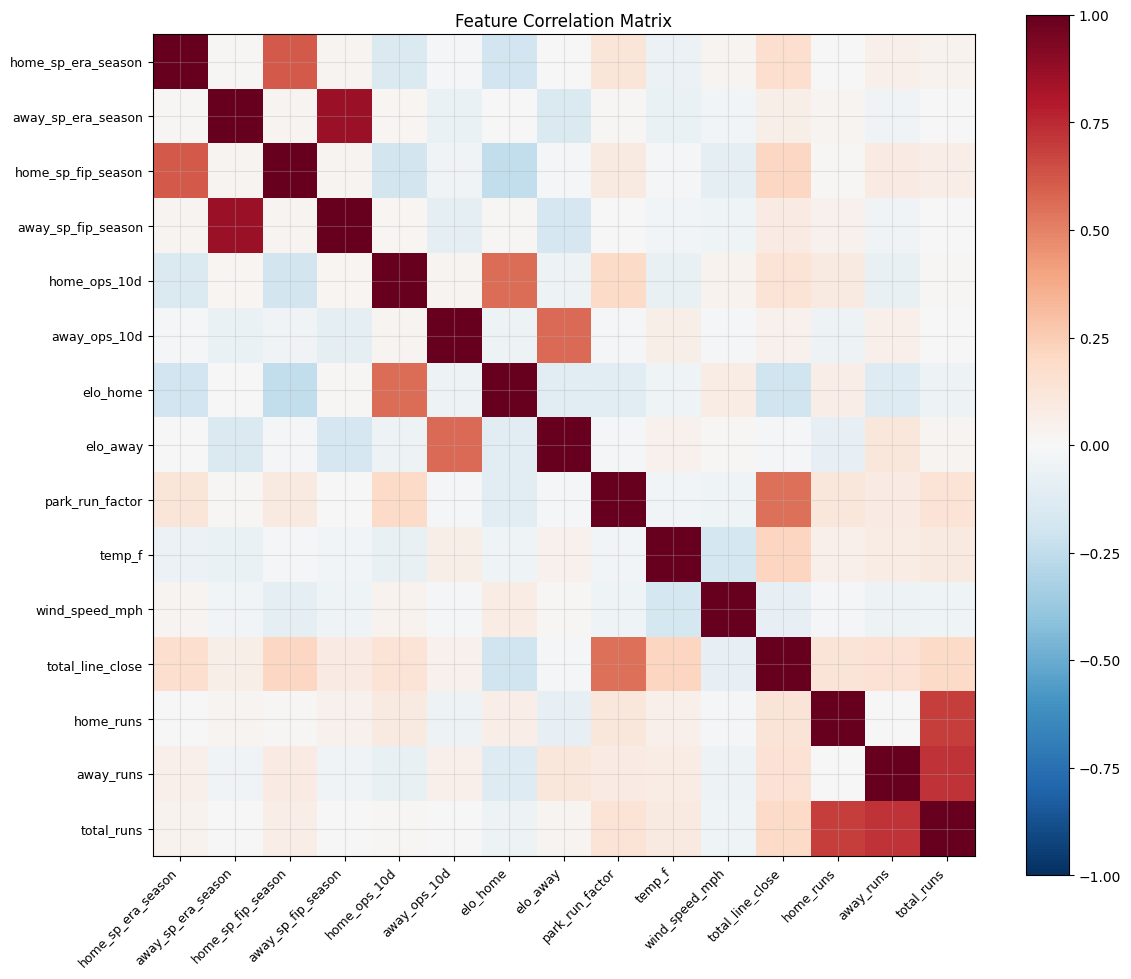

In [22]:
# Feature correlation heatmap (key numeric features only)
key_feats = [
    'home_sp_era_season', 'away_sp_era_season',
    'home_sp_fip_season', 'away_sp_fip_season',
    'home_ops_10d', 'away_ops_10d',
    'elo_home', 'elo_away',
    'park_run_factor', 'temp_f', 'wind_speed_mph',
    'total_line_close',
    'home_runs', 'away_runs', 'total_runs'
]
key_feats = [c for c in key_feats if c in df.columns]

corr_mat = df[key_feats].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(key_feats)))
ax.set_yticks(range(len(key_feats)))
ax.set_xticklabels(key_feats, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(key_feats, fontsize=9)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [23]:
# Top correlations with total_runs
if 'total_runs' in df.columns:
    target_corr = df[FEATURE_COLS].corrwith(df['total_runs']).dropna().abs().sort_values(ascending=False)
    print('Top 15 features correlated with total_runs:')
    print(target_corr.head(15).round(3).to_string())

Top 15 features correlated with total_runs:
total_line_close       0.190
total_line_open        0.164
park_run_factor        0.136
park_elevation_ft      0.127
park_hr_factor         0.126
temp_f                 0.090
line_movement          0.079
home_sp_fip_season     0.068
wind_dir_cross_left    0.057
wind_dir_in            0.056
sp_k9_combined         0.054
sp_fip_combined        0.050
elo_home               0.047
wind_speed_mph         0.046
home_sp_era_season     0.038


## 10. Data Quality Summary

In [24]:
checks = []

with get_conn(DB_PATH) as conn:
    n_games = conn.execute("SELECT COUNT(*) FROM games WHERE status='Final'").fetchone()[0]
    n_with_score = conn.execute("SELECT COUNT(*) FROM games WHERE total_runs IS NOT NULL").fetchone()[0]
    n_odds = conn.execute("SELECT COUNT(*) FROM sportsbook_odds WHERE total_close IS NOT NULL").fetchone()[0]
    n_weather = conn.execute("SELECT COUNT(*) FROM weather").fetchone()[0]
    n_elo = conn.execute("SELECT COUNT(*) FROM elo_ratings").fetchone()[0]
    n_pitchers = conn.execute("SELECT COUNT(*) FROM pitchers WHERE is_starter=1").fetchone()[0]
    n_parks = conn.execute("SELECT COUNT(*) FROM stadiums WHERE park_run_factor IS NOT NULL").fetchone()[0]

checks.append(('Games with results', n_with_score, n_with_score > 2000, f'{n_with_score} rows'))
checks.append(('Score completeness', n_with_score / n_games, n_with_score / n_games > 0.95, f'{n_with_score/n_games*100:.1f}%'))
checks.append(('Closing odds (Pinnacle)', n_odds, n_odds > 1000, f'{n_odds} rows'))
checks.append(('Weather rows', n_weather, n_weather > 500, f'{n_weather} rows'))
checks.append(('Elo rows', n_elo, n_elo > 1000, f'{n_elo} rows'))
checks.append(('Starter pitcher rows', n_pitchers, n_pitchers > 5000, f'{n_pitchers} rows'))
checks.append(('Park factors populated', n_parks, n_parks == 30, f'{n_parks} / 30'))

print('DATA QUALITY SUMMARY')
print('=' * 60)
all_pass = True
for name, value, passing, display in checks:
    status = 'PASS' if passing else 'FAIL'
    if not passing:
        all_pass = False
    print(f'  {status}  {name:<35} {display}')

print('=' * 60)
if all_pass:
    print('  GO: All checks pass — ready for Phase 3 (EDA + Modeling)')
else:
    print('  NO-GO: Fix failing checks before proceeding')

DATA QUALITY SUMMARY
  PASS  Games with results                  4074 rows
  PASS  Score completeness                  99.7%
  PASS  Closing odds (Pinnacle)             6006 rows
  PASS  Weather rows                        894 rows
  PASS  Elo rows                            5136 rows
  PASS  Starter pitcher rows                8112 rows
  PASS  Park factors populated              30 / 30
  GO: All checks pass — ready for Phase 3 (EDA + Modeling)
